https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

# preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from msi.utils import preprocessing, plotting, input_output
from msfm.utils import prior, parameters, files, logger, cross_statistics, scales

24-02-12 23:56:42   imports.py INF   Setting up healpy to run on 32 CPUs 
24-02-12 23:56:43   imports.py INF   Setting up healpy to run on 32 CPUs 


In [3]:
use_flow = True

if use_flow:
    import torch
    from msi.flow_conductor.likelihood_flow import LikelihoodFlow
    from msi.flow_conductor import architecture
else:
    import tensorflow as tf
    from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
    from msi.gaussian_mixture import architecture

# load the summary statistics

### v6

In [4]:
# lensing only
params = ["Om", "s8", "w0", "Aia", "n_Aia"]
with_lensing = True
with_clustering = False
with_cross_z = True
with_cross_probe = False

In [5]:
# # clustering only
# params = ["Om", "s8", "w0", "bg", "n_bg"]
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# with_cross_probe = False

In [6]:
# # combined probes
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# with_lensing = True
# with_clustering = True
# with_cross_z = True
# with_cross_probe = True

In [7]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")

# # base_dir = "/pscratch/sd/a/athomsen/DESY3/v6/linear_bias"
# base_dir = "/pscratch/sd/a/athomsen/DESY3/v7/linear_bias"

# # out_dir = "/pscratch/sd/a/athomsen/run_files/v6"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v7"

# pca_components = 32
# standardize = True

# # power spectrum scale cuts (in ell)
# n_bins = 33
# l_mins = 8 * [30]

# def angle_to_ell(angles):
#     return list(scales.angle_to_ell(np.array(angles), arcmin=True))

# # 2 Mpc/h
# mpc_fwhm = 2
# l_maxs = angle_to_ell(2 * [7.37791224, 5.03278194, 3.74696505, 3.1436941])

# # # 4 Mpc/h
# # mpc_fwhm = 4
# # l_maxs = angle_to_ell(2 * [14.75582447, 10.06556388, 7.4939301, 6.28738821])

# # # 6 Mpc/h
# # mpc_fwhm = 6
# # l_maxs = angle_to_ell(2 * [22.13373671, 15.09834582, 11.24089514, 9.43108231])

# # # 8 Mpc/h
# # mpc_fwhm = 8
# # l_maxs = angle_to_ell(2 * [29.51164894, 20.13112776, 14.98786019, 12.57477642])

# # # 10 Mpc/h
# # mpc_fwhm = 10
# # l_maxs = angle_to_ell(2 * [36.88956118, 25.1639097, 18.73482524, 15.71847052])

# label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components},fwhm={mpc_fwhm},standard={standardize}"

In [8]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")

# base_dir = "/pscratch/sd/a/athomsen/DESY3/v6/linear_bias"
base_dir = "/pscratch/sd/a/athomsen/DESY3/v7/linear_bias"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v6"
out_dir = "/pscratch/sd/a/athomsen/run_files/v7"

pca_components = 50
standardize = False

# power spectrum scale cuts (in ell)
n_bins = 33
l_mins = 8 * [30]                

l_maxs = list(scales.angle_to_ell(np.array([23.03, 16.28, 13.29, 9.4, 65.13, 45.08, 35.17, 29.73]), arcmin=True))
# l_maxs = list(scales.angle_to_ell(np.array([10] * 8), arcmin=True))

label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components}"

#### power spectra

24-02-12 23:56:54 preprocessin INF   Applying scale cuts to the raw Cls 
24-02-12 23:56:54 preprocessin INF   l_mins = [30, 30, 30, 30, 30, 30, 30, 30] 
24-02-12 23:56:54 preprocessin INF   l_maxs = [468.9535388623534, 663.3906633906633, 812.6410835214447, 1148.936170212766, 165.82220175034547, 239.57409050576754, 307.0798976400341, 363.2694248234107] 
24-02-12 23:56:55 input_output INF   Array shapes: 
24-02-12 23:56:55 input_output INF   fiducial/i_example = (2400,) 
24-02-12 23:56:55 input_output INF   fiducial/i_noise   = (2400,) 
24-02-12 23:56:55 input_output INF   fiducial/cls/binned = (2400, 32, 36) 
24-02-12 23:56:55 input_output INF   fiducial/cls/bin_edges = (33, 36) 
24-02-12 23:56:55 input_output INF   grid/cosmo         = (2500, 48, 10) 
24-02-12 23:56:55 input_output INF   grid/i_example     = (2500, 48) 
24-02-12 23:56:55 input_output INF   grid/i_noise       = (2500, 48) 
24-02-12 23:56:55 input_output INF   grid/i_sobol       = (2500, 48) 
24-02-12 23:56:56 input_outp

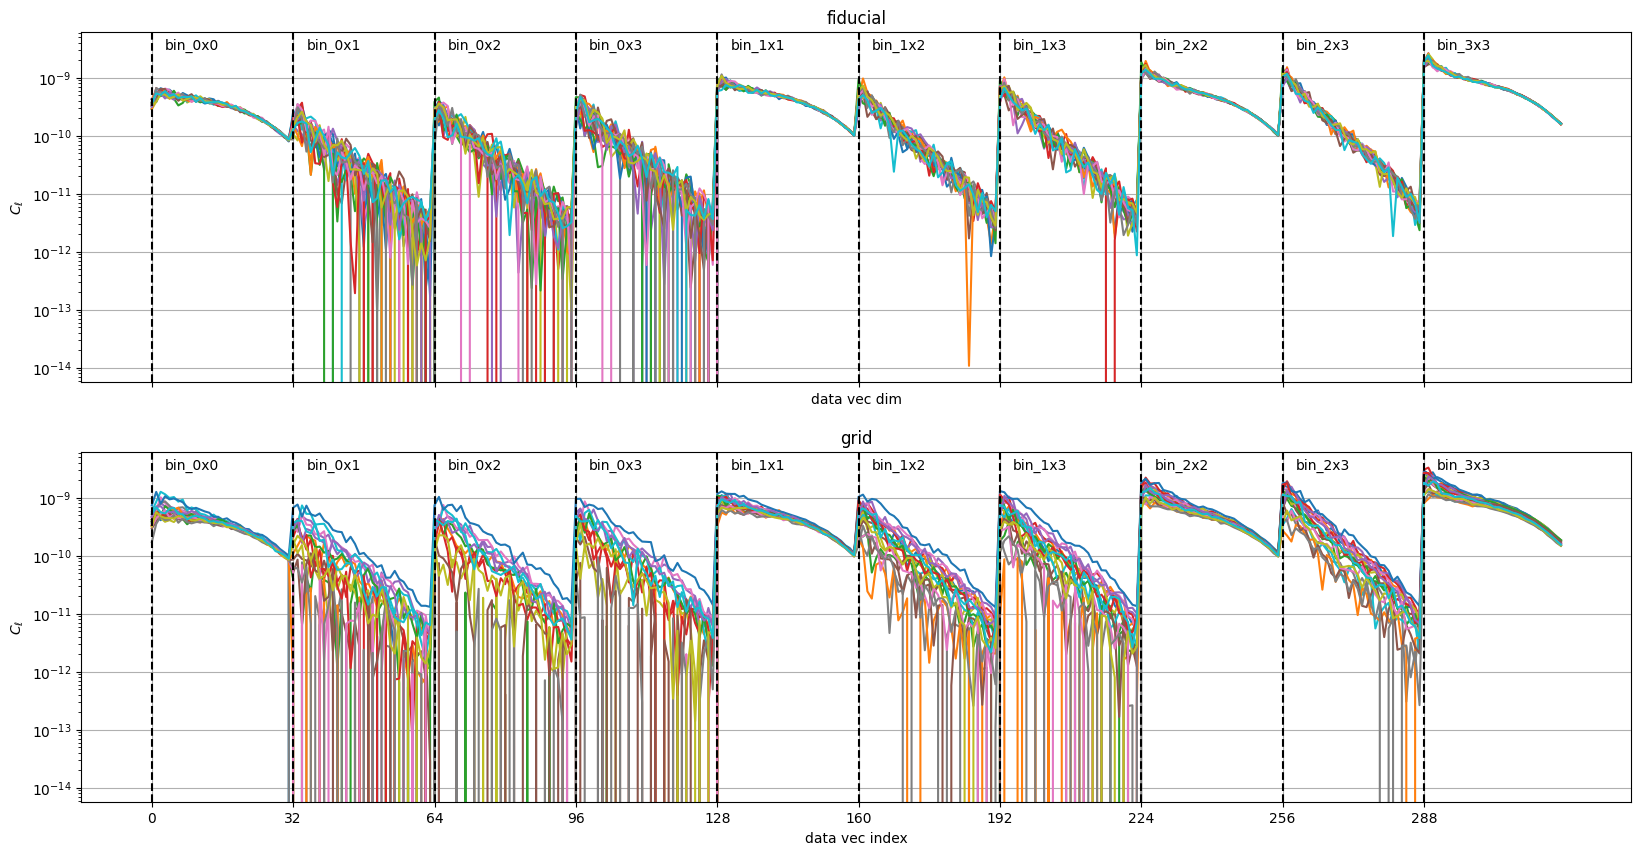

In [9]:
summary = "cls"
# summary = "peaks"

fidu_summs, grid_summs, grid_cosmos, file_dict = preprocessing.get_reshaped_human_summaries(
    base_dir, 
    summary, 
    # file
    file_label=None,
    # configuration
    conf=conf, 
    params=params,
    concat_example_dim=True,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=with_cross_probe,
    # power spectra: scales
    l_mins=l_mins,
    l_maxs=l_maxs,
    n_bins=n_bins,
    # peaks: scales
    scale_indices=None,
    # additional preprocessing
    standardize=standardize,
    apply_log=False,
    pca_components=pca_components,
)

out_dir = os.path.join(out_dir, summary) if (os.path.basename(out_dir) != summary) else out_dir
os.makedirs(out_dir, exist_ok=True)

# likelihood model $p(x|\theta)$

### flow

In [10]:
# input dimensions
x_dim = grid_summs.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 32,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=5,
#     hidden_dim=128,
# )

model = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label,
    load_existing=True,
)

24-02-12 23:57:00 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v7/cls/lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=50/likelihood_flow 
24-02-12 23:57:00 likelihood_f INF   Initialized the normalizing flow 
24-02-12 23:57:01 likelihood_f INF   Running on device cuda with default float torch.float32 
24-02-12 23:57:01 likelihood_f WAR   Could not load the model from /pscratch/sd/a/athomsen/run_files/v7/cls/lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=50/likelihood_flow/likelihood_flow.pt 


In [11]:
# model.fit(
#     x=grid_summs,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=1000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=100.0,
#     # scheduler
#     scheduler_type="cosine",
#     # early stopping
#     n_patience_epochs=10,
#     min_delta=0.0,
#     save_model=True,
# )

24-02-12 23:57:03 likelihood_f INF   Using a cosine annealing scheduler 
100%|████████████████████████████|   | 100/100 [04:59<00:00,  3.00s/it]       lr: 1.00E-05, train: 52.86, vali: 53.89: 
24-02-13 00:02:03 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v7/cls/lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=50/likelihood_flow/likelihood_flow.pt 


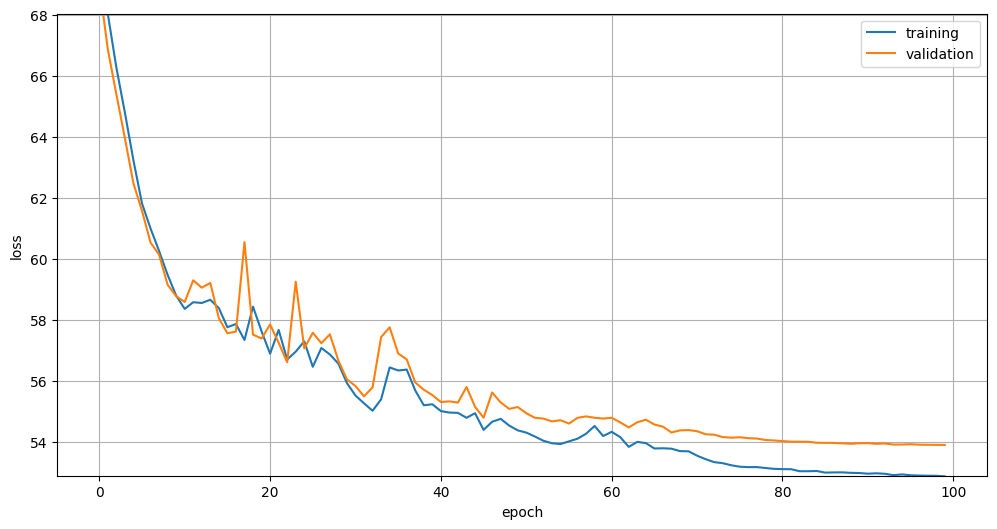

In [12]:
model.fit(
    x=grid_summs,
    theta=grid_cosmos,
    n_epochs=100,
    # dataset
    batch_size=10000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    # scheduler
    scheduler_type="cosine",
    # early stopping
    n_patience_epochs=None,
    min_delta=0.0,
    save_model=True,
)

### Gaussian mixture

In [13]:
# layers = architecture.get_gmm_layers(
#     n_x=grid_summs.shape[-1],
#     n_theta=grid_cosmos.shape[-1],
#     n_gaussians=4,
#     n_units=256,
#     n_layers=4,
# )

# model = LikelihoodGMM(
#     params, 
#     conf, 
#     layers=layers,
#     out_dir=out_dir, 
#     label=label,
#     # load_existing=False,
# )

In [14]:
# model.fit(
#     x=grid_summs,
#     theta=grid_cosmos,
#     n_epochs=1000,
#     # dataset
#     batch_size=10000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     learning_rate_min=1e-8,
#     # early stopping
#     n_patience_epochs=100,
#     min_delta=0.001,
#     save_model=True,
# )

### convergence tests

In [15]:
# _, raw_grid_summs, raw_grid_cosmos, _ = preprocessing.get_reshaped_human_summaries(
#     base_dir, 
#     summary, 
#     # file
#     do_plot=False,
#     file_label=None,
#     # configuration
#     conf=conf, 
#     params=params,
#     concat_example_dim=False,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     with_cross_z=with_cross_z,
#     with_cross_probe=with_cross_probe,
#     # power spectra: scales
#     l_mins=l_mins,
#     l_maxs=l_maxs,
#     n_bins=n_bins,
#     # peaks: scales
#     scale_indices=None,
#     # additional preprocessing
#     standardize=False,
#     apply_log=False,
#     pca_components=pca_components,
# )

# # this applies to the cls, not the peaks. TODO this is a bit hacky
# if raw_grid_cosmos.ndim==3:
#     raw_grid_cosmos = raw_grid_cosmos[:,0,:]

# _ = model.plot_diagnostics(
#     # these must be the raw arrays where the cosmo and example axis are still separate
#     grid_preds_true=raw_grid_summs, 
#     grid_cosmos=raw_grid_cosmos,
#     n_samples=100,
#     do_hist=False,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

### observation

In [16]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))

print(f"Using the example index {i_obs}")
obs_pred = fidu_summs[i_obs]

Using the example index 0


### MCMC

In [17]:
posterior_samples = model.sample_posterior(
    obs_pred,
)

24-02-13 00:02:07      mcmc.py INF   Initial values in prior: True 
24-02-13 00:02:07      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-02-13 00:02:17      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:41<00:00, 11.92it/s]

24-02-13 00:02:59      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v7/cls/lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=50/likelihood_flow/chain.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-02-13 00:03:03  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v7/cls/lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=50/likelihood_flow/contours.png 


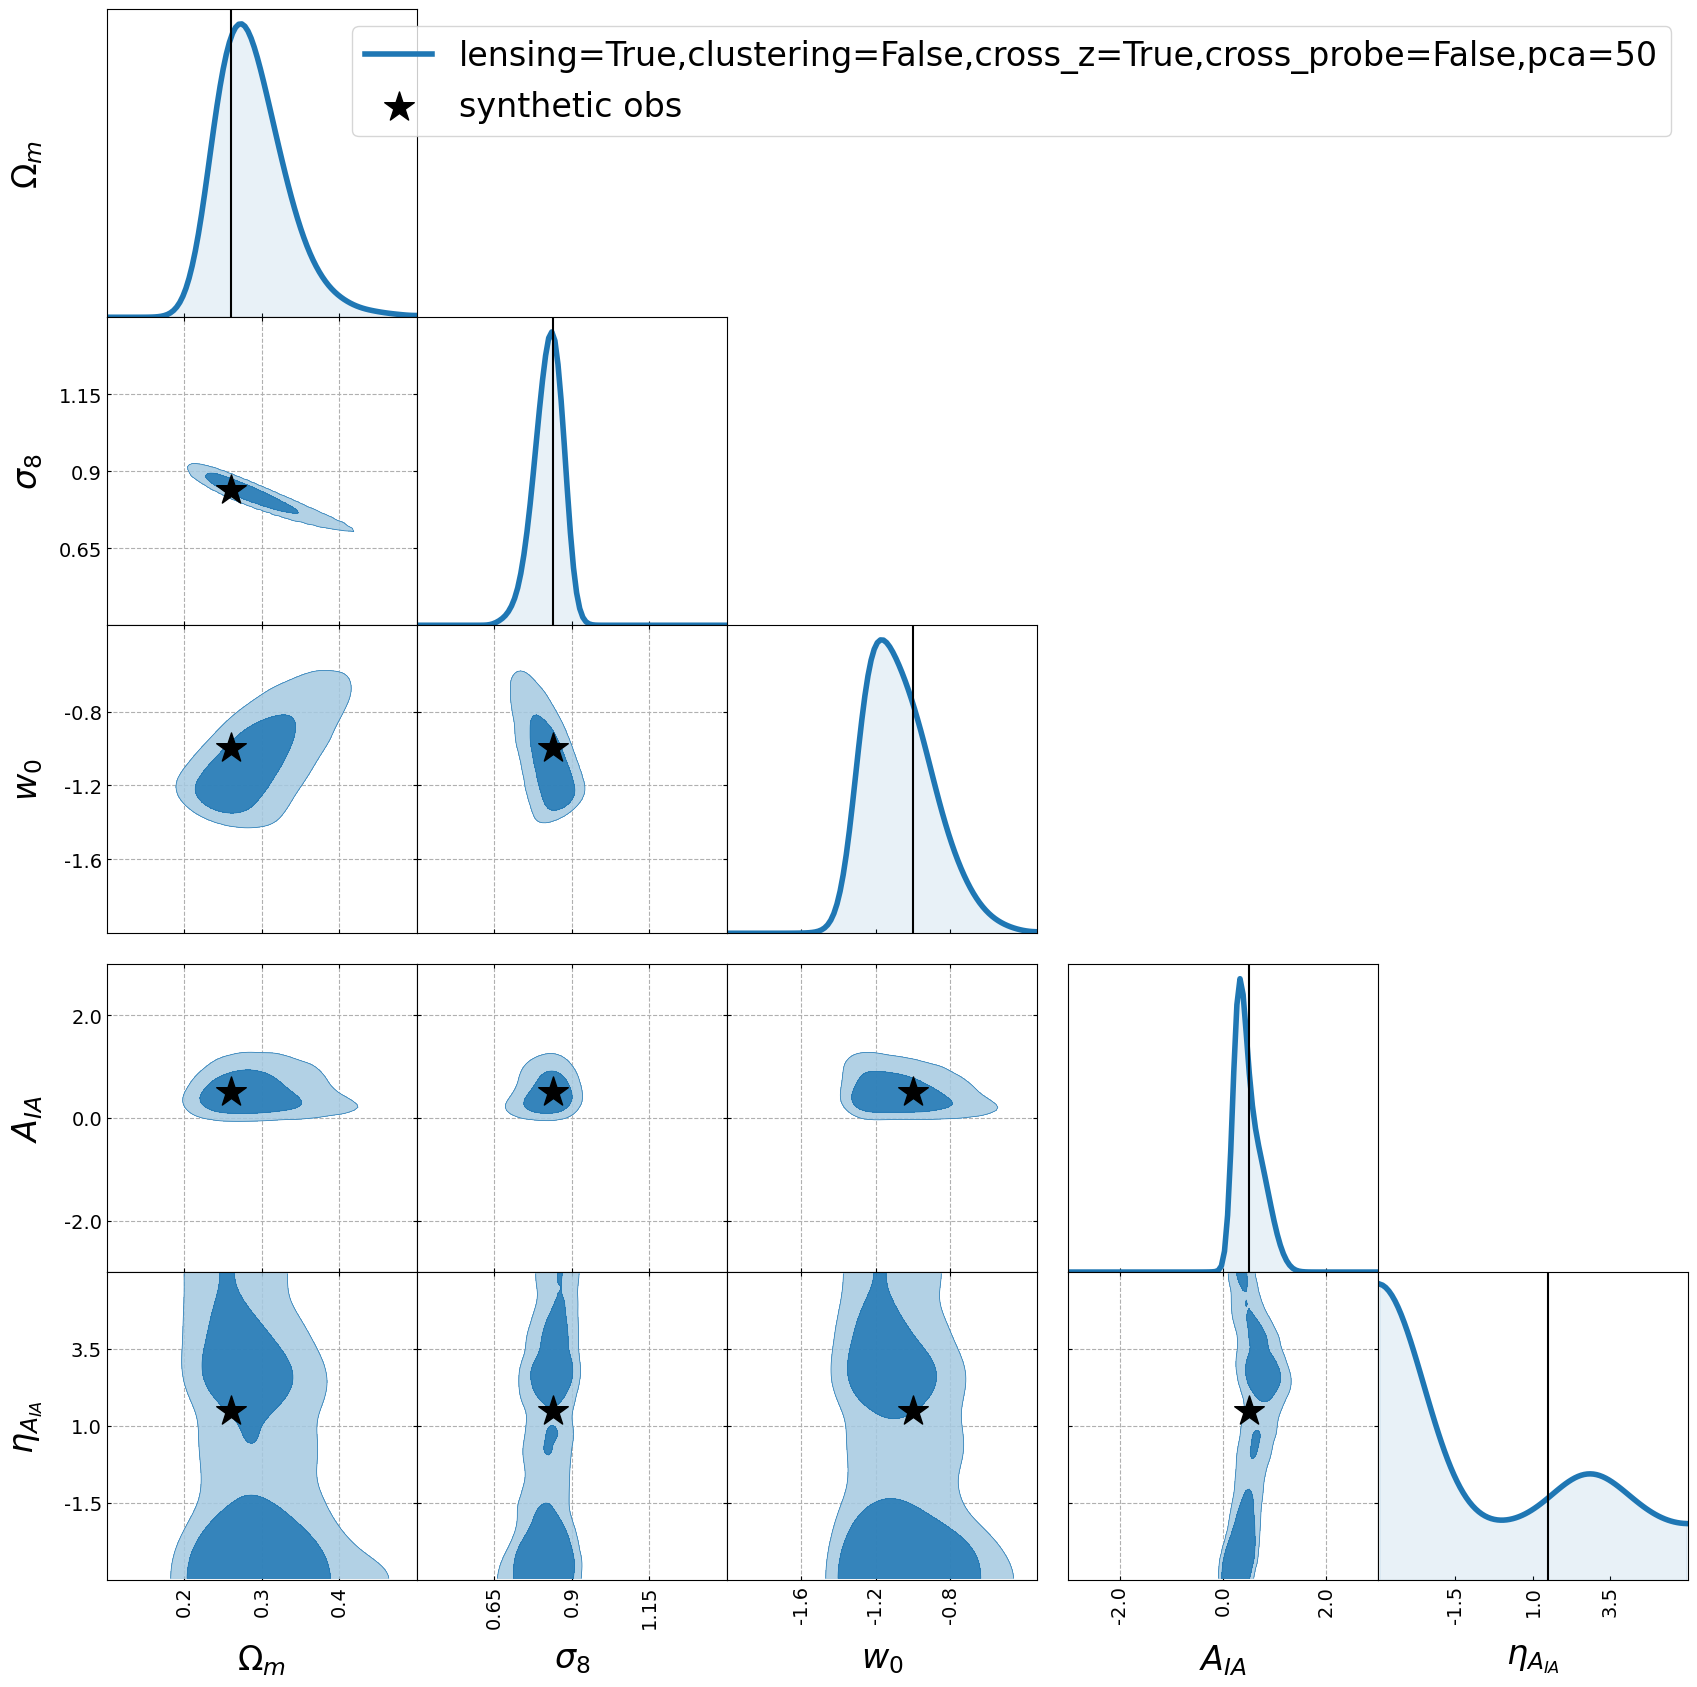

In [18]:
model.plot_contours(
    posterior_samples,
    with_des_chain=False,
)